<a href="https://colab.research.google.com/github/gkambasta/ML-Projects/blob/main/Assign801V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def gen_response():

    act = [ random.randint(100,200) for i in range(1,100)]
    trad = [ random.randint(100,200) for i in range(1,100)]
    aiml = [ random.randint(100,200) for i in range(1,100)]

    df = pd.DataFrame([act,trad,aiml]).transpose()
    df['abserr_trad'] = abs(df[0] - df[1])
    df['abserr_aiml'] = abs(df[0] - df[2])

    df = pd.DataFrame({ "Actuals" : act,
                   "Traditional" : trad,
                   "AIML" : aiml })

    df['abserr_trad'] = abs(df['Actuals'] - df['Traditional'])
    df['abserr_aiml'] = abs(df['Actuals'] - df['AIML'])

    wMAPE_trad_ibp = abs(sum(df.Actuals) - sum(df.Traditional))/sum(df.Actuals)
    wMAPE_aiml_ibp = abs(sum(df.Actuals) - sum(df.AIML))/sum(df.Actuals)
    wMAPE_trad_exe = sum(df.abserr_trad)/sum(df.Actuals)
    wMAPE_aiml_exe = sum(df.abserr_aiml)/sum(df.Actuals)

    rmse_trad_exe = root_mean_squared_error(df.Actuals, df.Traditional)
    rmse_aiml_exe = root_mean_squared_error(df.Actuals, df.AIML)
    rmse_trad_ibp = root_mean_squared_error([df.Actuals.sum()], [df.Traditional.sum()])/len(df)
    rmse_aiml_ibp = root_mean_squared_error([df.Actuals.sum()], [df.AIML.sum()])/len(df)

    response = [wMAPE_trad_ibp, wMAPE_aiml_ibp, wMAPE_trad_exe, wMAPE_aiml_exe, rmse_trad_ibp, rmse_aiml_ibp, rmse_trad_exe, rmse_aiml_exe]

    return response


In [ ]:
df.describe()

,wmape_trad_ibp,wmape_aiml_ibp,wmape_trad_exe,wmape_aiml_exe,rmse_trad_ibp,rmse_aiml_ibp,rmse_trad_exe,rmse_aiml_exe,PE_trad_wmape,PE_aiml_wmape,PE_trad_rmse,PE_aiml_rmse
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,0.019147,0.019172,0.222873,0.222443,2.871034,2.870932,40.969138,40.866279,45.082917,48.940950,55.241605,60.180758
std,0.014956,0.014810,0.018153,0.017888,2.246427,2.208715,2.711238,2.636678,138.398071,180.688947,166.794334,221.765839
min,0.000197,0.000132,0.171345,0.170062,0.030303,0.020202,32.812445,33.778243,2.461864,2.489247,3.277705,3.017669
25%,0.006341,0.007458,0.212911,0.211087,0.964646,1.111111,39.728365,39.289279,7.292683,7.503470,9.194736,9.719858
50%,0.016061,0.017221,0.223447,0.223104,2.434343,2.555556,41.248569,40.874778,12.275556,12.304348,15.502954,15.382840
75%,0.027051,0.024828,0.231479,0.234967,4.070707,3.803030,42.448662,42.471142,34.336404,28.638177,42.300347,35.566731
max,0.065518,0.071893,0.258876,0.257335,9.949495,11.272727,47.074516,46.423718,1268.000000,1643.000000,1521.424711,2019.081805


In [ ]:
all_responses = [gen_response() for i in range(99)]
df =  pd.DataFrame(all_responses)
df.columns = ["wmape_trad_ibp", "wmape_aiml_ibp", "wmape_trad_exe", "wmape_aiml_exe","rmse_trad_ibp", "rmse_aiml_ibp", "rmse_trad_exe", "rmse_aiml_exe"]


In [ ]:
#statistical test functions

def paired_tstat_onetail(x1,x2):

    t_statistic, p_value = stats.ttest_rel(x1,x2,alternative = 'greater')

    return ({'tvalue': round(t_statistic,3), 'pvalue': round(p_value,3)})

def paired_tstat_twotail(x1,x2):

    t_statistic, p_value = stats.ttest_rel(x1,x2)

    return ({'tvalue': round(t_statistic,3), 'pvalue': round(p_value,3)})

In [ ]:
df["PE_trad_wmape"] = (df['wmape_trad_exe'] - df["wmape_trad_ibp"])/df["wmape_trad_ibp"]
df["PE_aiml_wmape"] = (df['wmape_aiml_exe'] - df["wmape_aiml_ibp"])/df["wmape_aiml_ibp"]
df["PE_trad_rmse"]  = (df['rmse_trad_exe'] - df["rmse_trad_ibp"])/df["rmse_trad_ibp"]
df["PE_aiml_rmse"] = (df['rmse_aiml_exe'] - df["rmse_aiml_ibp"])/df["rmse_aiml_ibp"]

In [ ]:
df.head()

,wmape_trad_ibp,wmape_aiml_ibp,wmape_trad_exe,wmape_aiml_exe,rmse_trad_ibp,rmse_aiml_ibp,rmse_trad_exe,rmse_aiml_exe,PE_trad_wmape,PE_aiml_wmape,PE_trad_rmse,PE_aiml_rmse
0,0.021982,0.008915,0.226827,0.224105,3.262626,1.323232,41.207899,40.707257,9.318885,24.137405,11.630285,29.763500
1,0.039837,0.005107,0.211304,0.200953,5.909091,0.757576,39.006733,37.992423,4.304274,38.346667,5.601140,49.149999
2,0.000197,0.016400,0.249738,0.256888,0.030303,2.525253,46.134082,45.786284,1268.000000,14.664000,1521.424711,17.131369
3,0.000944,0.021584,0.201943,0.199919,0.141414,3.232323,38.890159,37.692536,212.857143,8.262500,274.008979,10.661128
4,0.018725,0.020843,0.242602,0.202351,2.767677,3.080808,42.761023,36.886257,11.956204,8.708197,14.450150,10.972916


In [ ]:
print(len(df))
if (np.isinf(df).values.any()):

    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print("inf values removed")

99


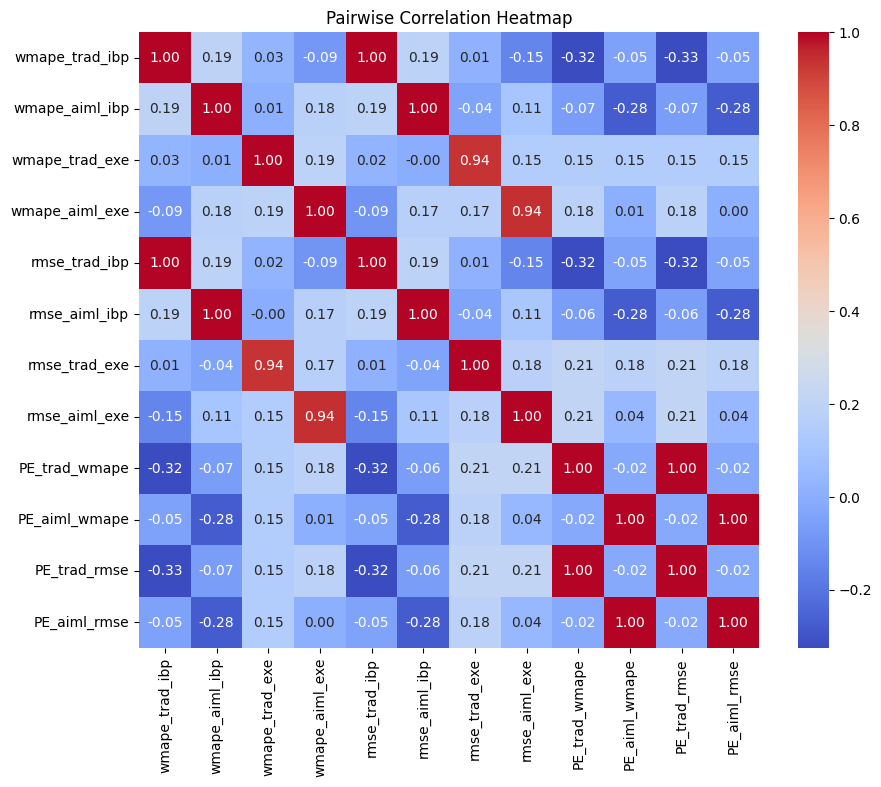

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pairwise Correlation Heatmap')
plt.show()

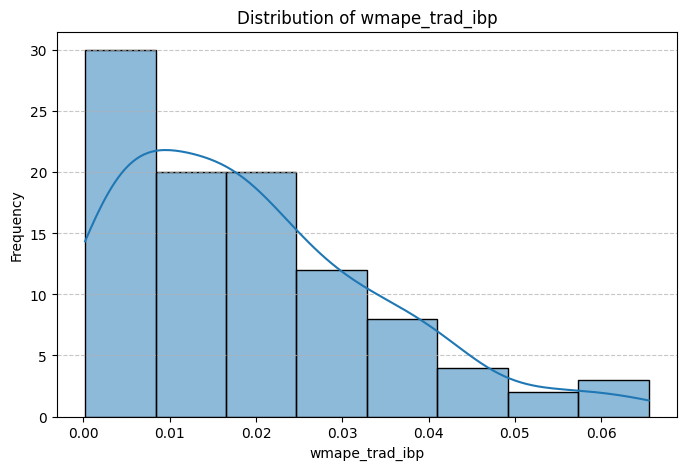

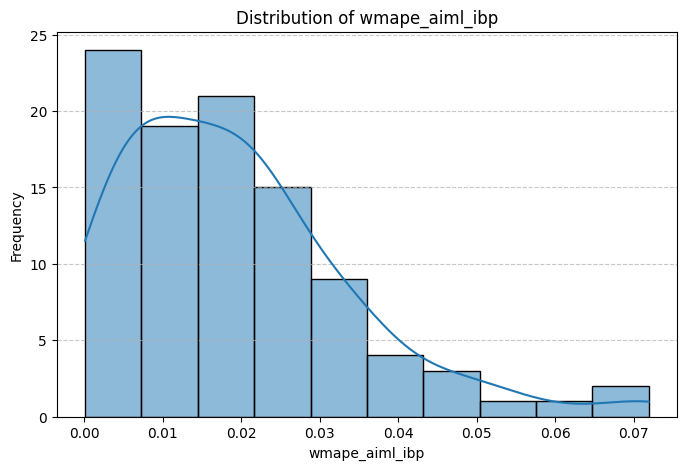

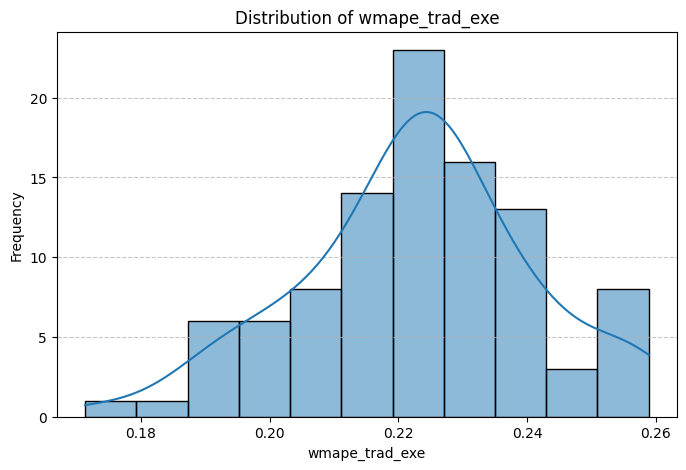

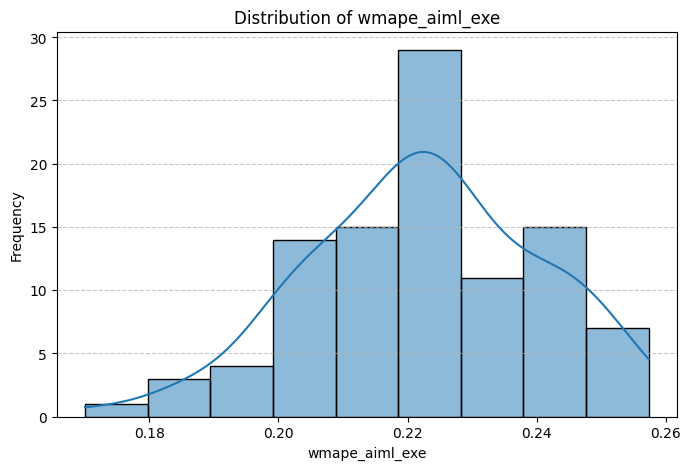

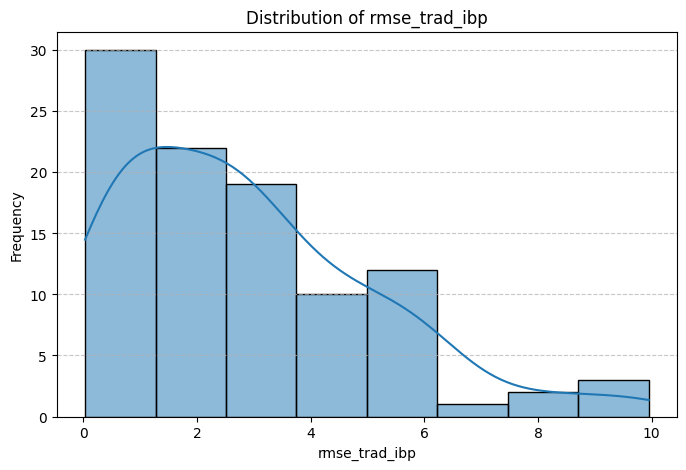

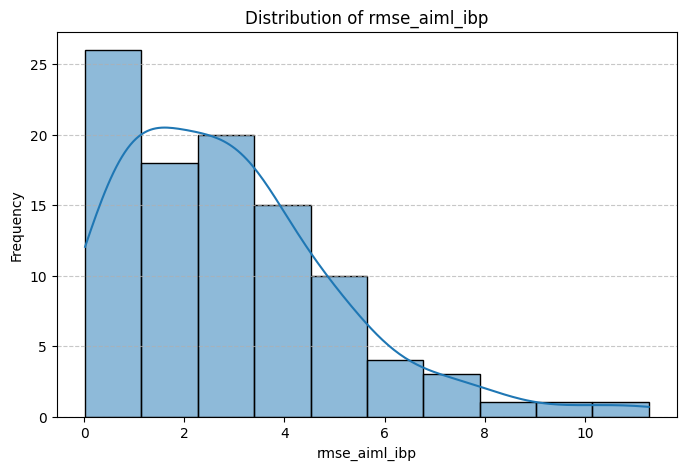

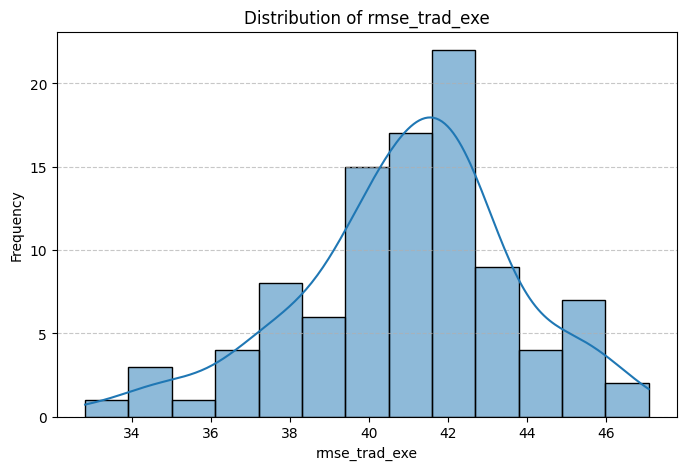

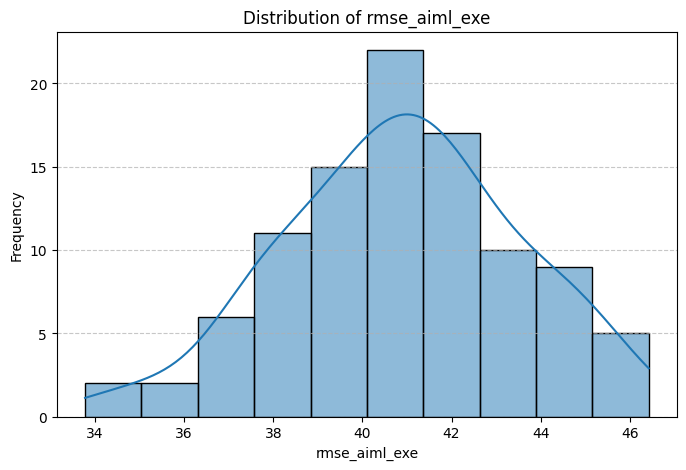

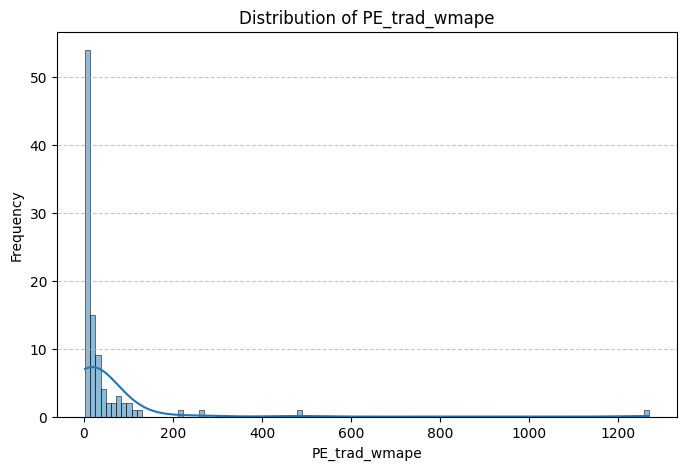

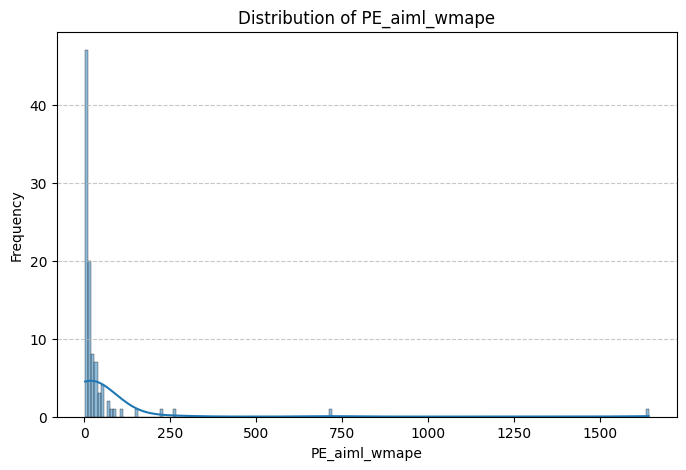

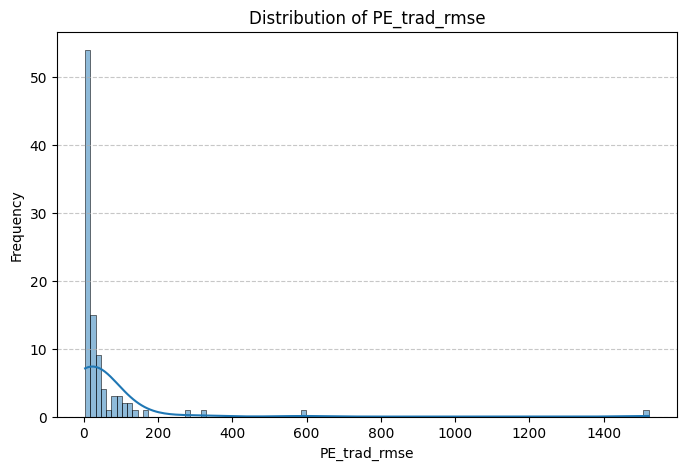

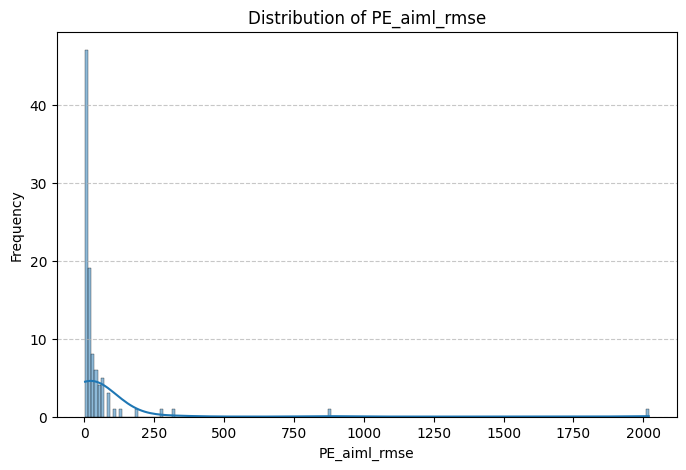

In [ ]:
for column in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

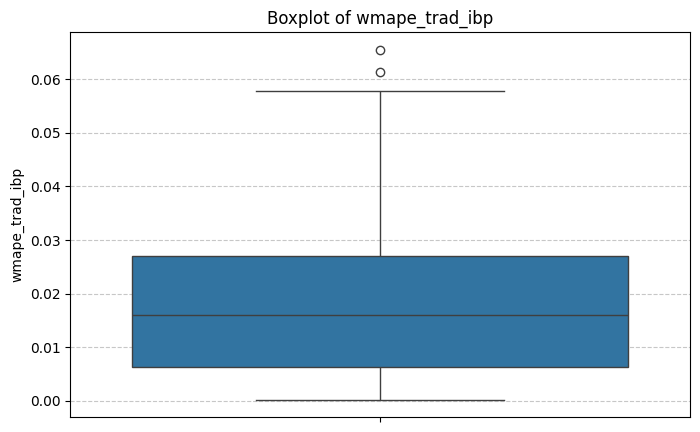

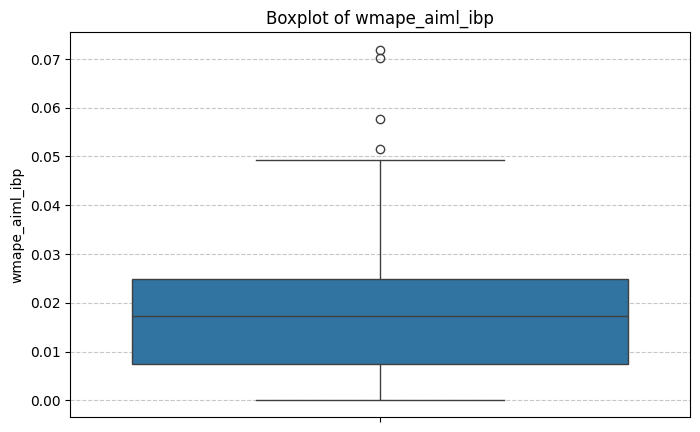

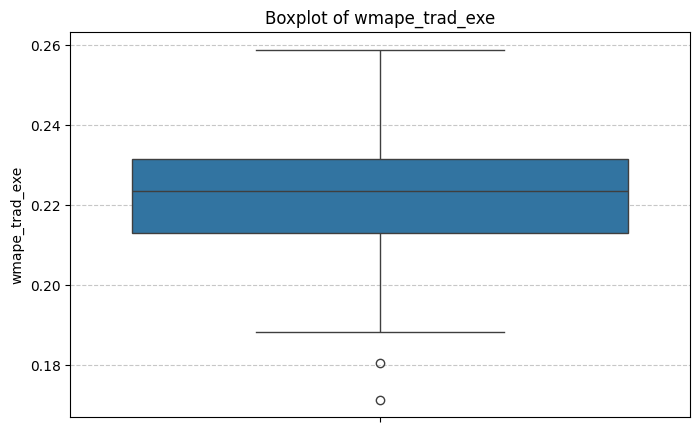

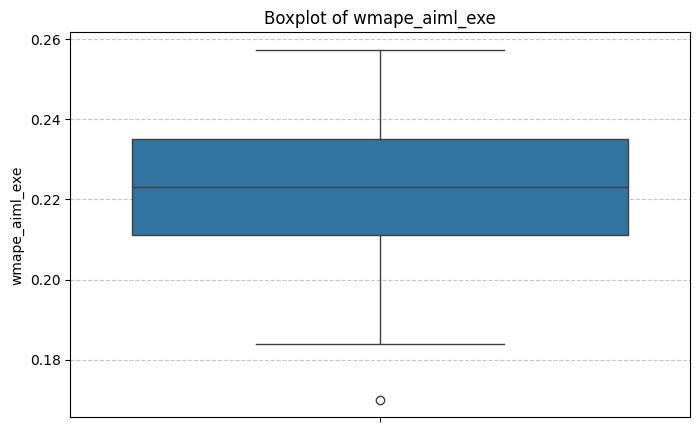

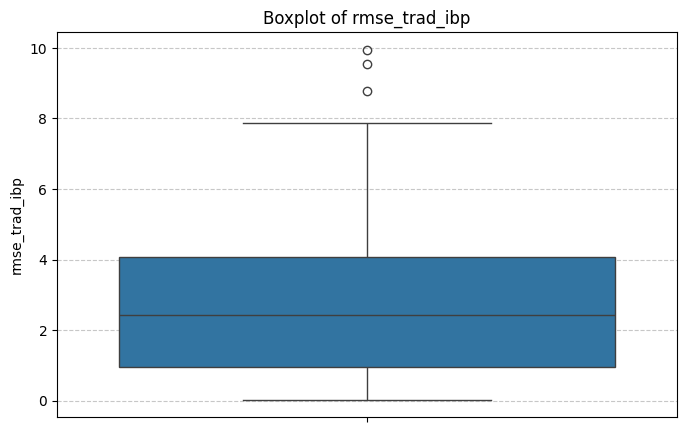

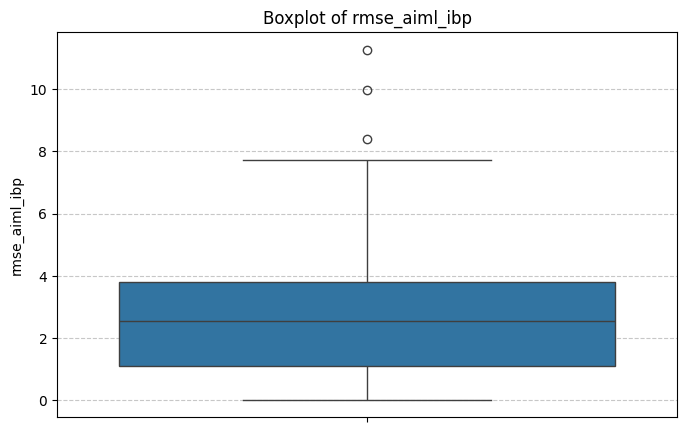

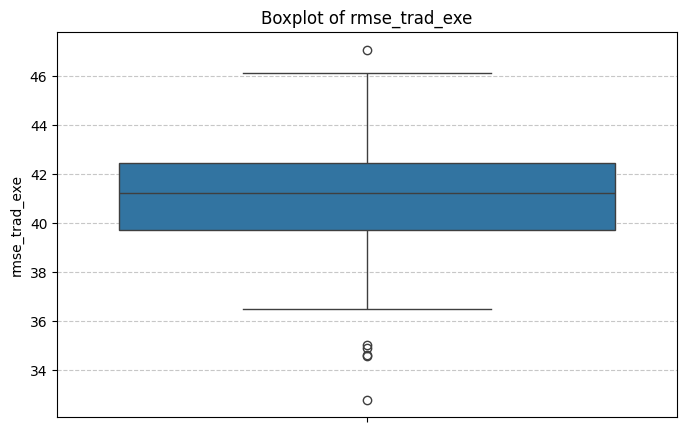

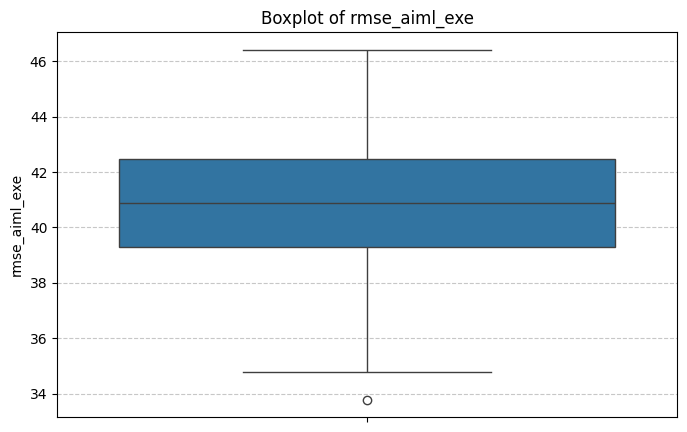

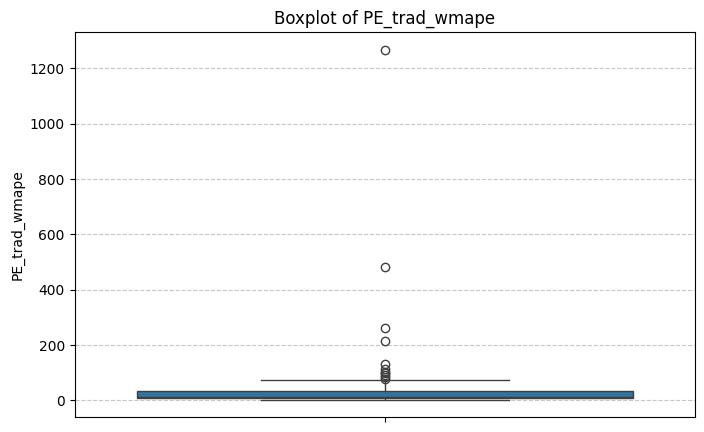

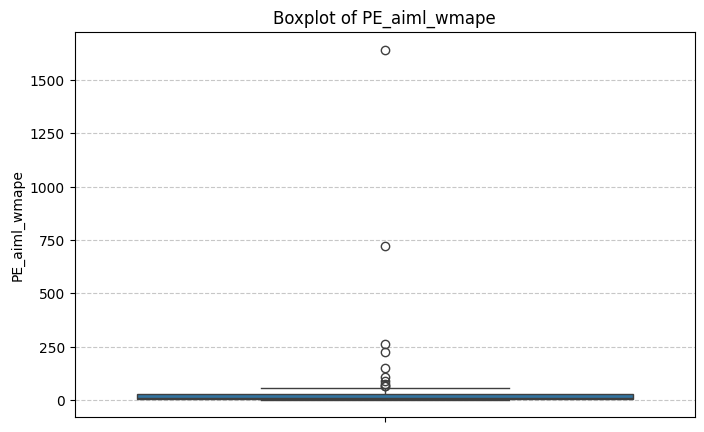

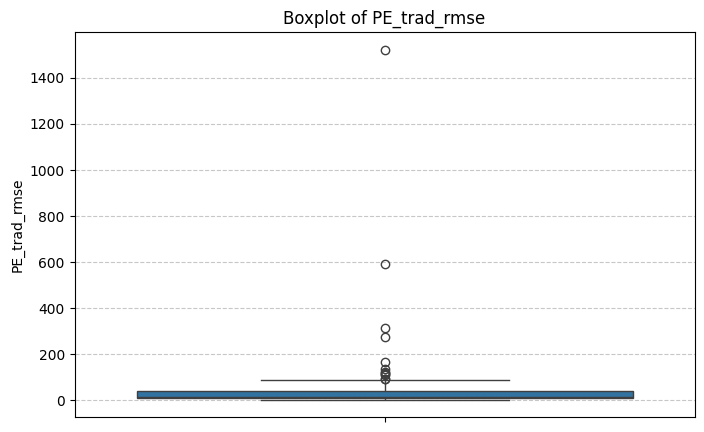

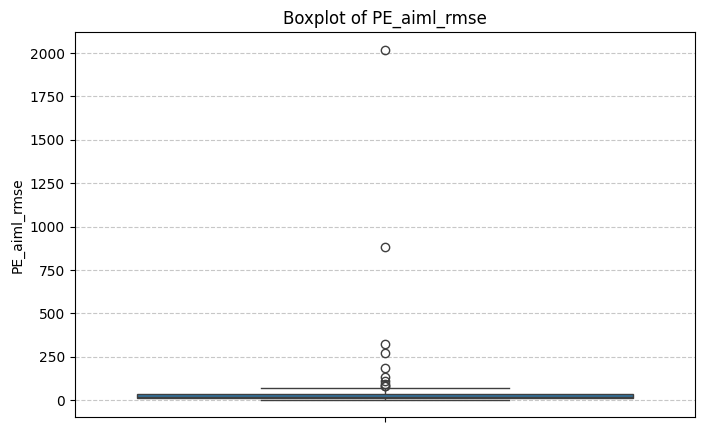

In [ ]:
for column in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

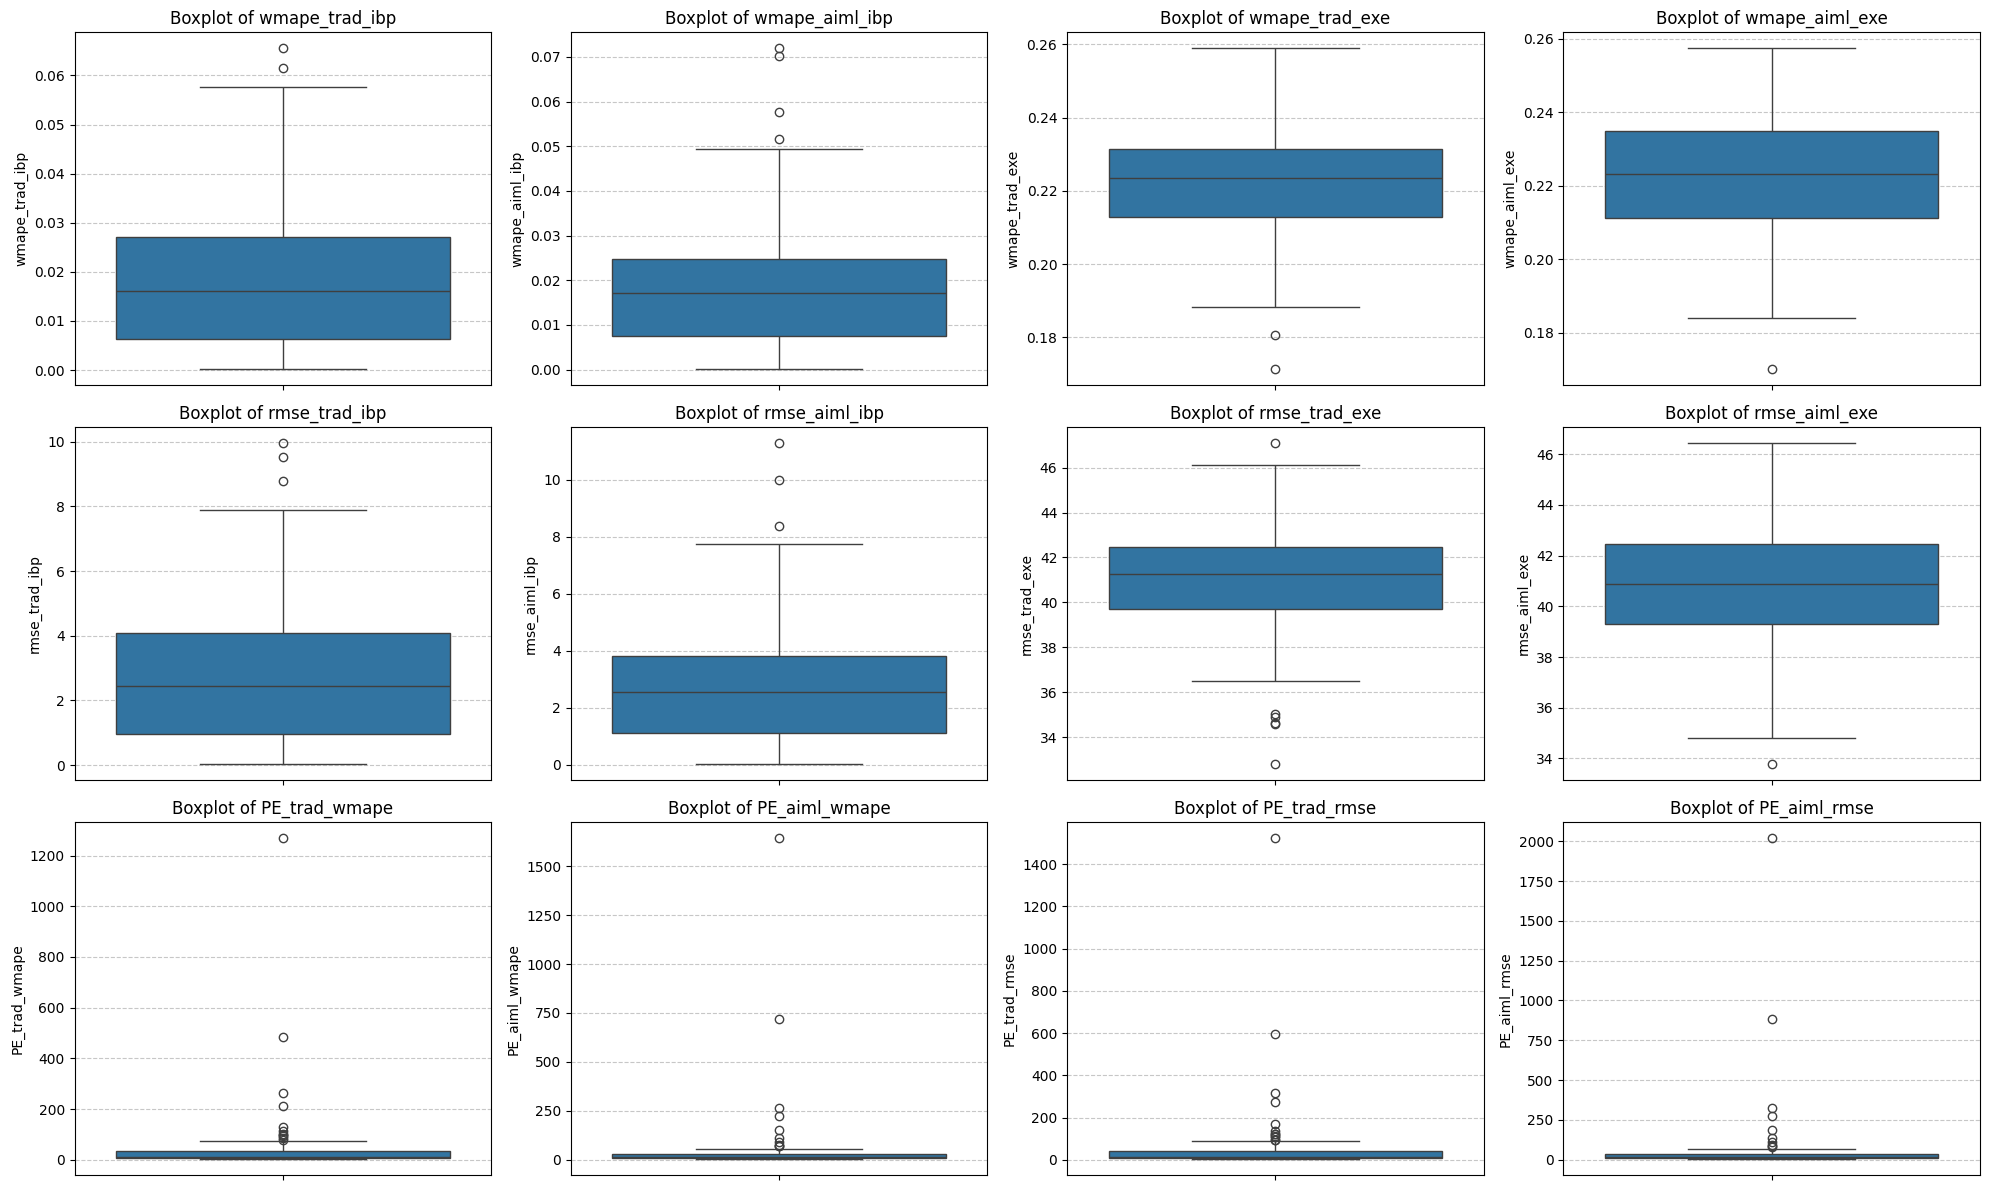

In [ ]:
n_cols = len(df.columns)
n_rows = 3
n_cols_per_row = (n_cols + n_rows - 1) // n_rows  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(5 * n_cols_per_row, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, column in enumerate(df.columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(f'Boxplot of {column}')
    axes[i].set_ylabel(column)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

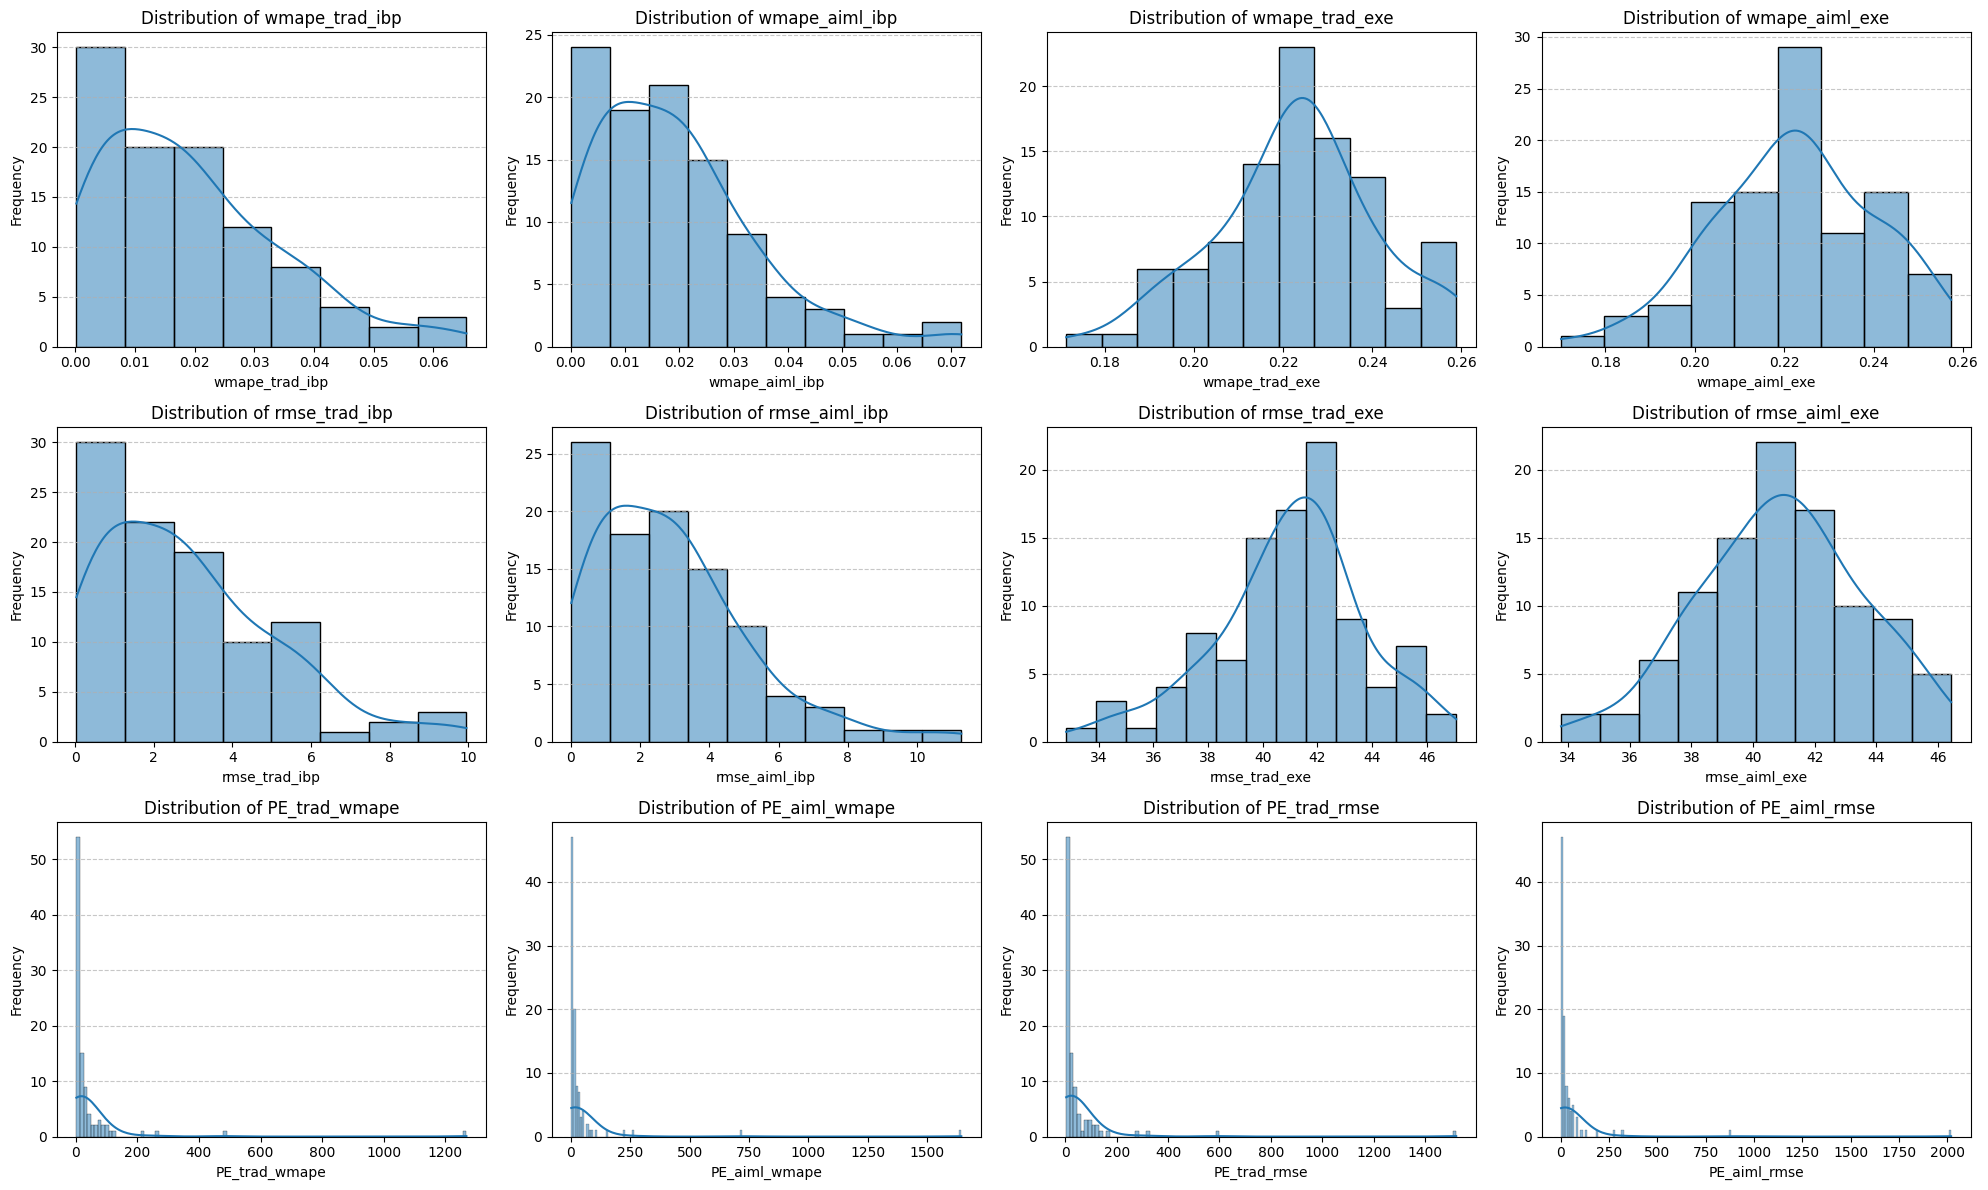

In [ ]:
n_cols = len(df.columns)
n_rows = 3
n_cols_per_row = (n_cols + n_rows - 1) // n_rows  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(5 * n_cols_per_row, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, column in enumerate(df.columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
def ttest_results(df):
    hypo1 = pd.DataFrame([paired_tstat_onetail(df.wmape_trad_exe, df.wmape_aiml_exe)])
    hypo2 = pd.DataFrame([paired_tstat_onetail(df.wmape_trad_exe, df.wmape_trad_ibp)])
    hypo3 = pd.DataFrame([paired_tstat_onetail(df.wmape_aiml_exe, df.wmape_aiml_ibp)])
    hypo4 = pd.DataFrame([paired_tstat_twotail(df.PE_trad_wmape, df.PE_aiml_wmape)])
    hypo5 = pd.DataFrame([paired_tstat_twotail(df.PE_trad_rmse, df.PE_aiml_rmse)])
    hypo6 = pd.DataFrame([paired_tstat_twotail(df.PE_trad_wmape, df.PE_trad_rmse)])

    df_result = pd.concat([hypo1,hypo2, hypo3,hypo4, hypo5, hypo6],ignore_index = True)

    return df_result

In [ ]:
ttest_results(df)

,tvalue,pvalue
0,0.187,0.426
1,87.502,0.000
2,95.716,0.000
3,-0.167,0.868
4,-0.175,0.861
5,-3.547,0.001


In [ ]:
df.to_csv('responses.csv', index = False)

In [ ]:
df1 = pd.read_csv('responses.csv')
df1

,wmape_trad_ibp,wmape_aiml_ibp,wmape_trad_exe,wmape_aiml_exe,rmse_trad_ibp,rmse_aiml_ibp,rmse_trad_exe,rmse_aiml_exe,PE_trad_wmape,PE_aiml_wmape,PE_trad_rmse,PE_aiml_rmse
0,0.021982,0.008915,0.226827,0.224105,3.262626,1.323232,41.207899,40.707257,9.318885,24.137405,11.630285,29.763500
1,0.039837,0.005107,0.211304,0.200953,5.909091,0.757576,39.006733,37.992423,4.304274,38.346667,5.601140,49.149999
2,0.000197,0.016400,0.249738,0.256888,0.030303,2.525253,46.134082,45.786284,1268.000000,14.664000,1521.424711,17.131369
3,0.000944,0.021584,0.201943,0.199919,0.141414,3.232323,38.890159,37.692536,212.857143,8.262500,274.008979,10.661128
4,0.018725,0.020843,0.242602,0.202351,2.767677,3.080808,42.761023,36.886257,11.956204,8.708197,14.450150,10.972916
...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.012918,0.014754,0.229180,0.203738,1.989899,2.272727,42.445092,38.462496,16.741117,12.808889,20.330275,15.923498
95,0.015200,0.000790,0.258669,0.210041,2.333333,0.121212,47.074516,39.168891,16.017316,265.000000,19.174793,322.143351
96,0.001563,0.011758,0.204921,0.245429,0.232323,1.747475,39.309572,44.392533,130.086957,19.872832,168.202069,24.403819
97,0.002170,0.015912,0.215991,0.208298,0.333333,2.444444,40.293494,40.046942,98.545455,12.090909,119.880482,15.382840


In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
datadf = df1.iloc[:, 0:8]

In [ ]:
import pingouin as pg
alpha, ci = pg.cronbach_alpha(df1)

print(f"Cronbach's Alpha: {alpha:.3f}")

Cronbach's Alpha: 0.530


In [ ]:
data = df1.copy()
standardized_data = (data - data.mean()) / data.std()

# 3. Calculate Alpha using Pingouin
alpha_output = pg.cronbach_alpha(data=standardized_data)

# 4. Extract and print results
alpha_value, confidence_interval = alpha_output[0], alpha_output[1]
print(f"Standardized Cronbach's Alpha: {alpha_value:.3f}")
print(f"95% Confidence Interval: {confidence_interval}")

Standardized Cronbach's Alpha: 0.578
95% Confidence Interval: [0.444 0.691]


In [ ]:
df1.wmape_trad_exe.mean()

np.float64(0.22287341147001982)

In [ ]:

def cochran_sample_size(confidence_level=0.95, margin_of_error=0.05, estimated_proportion=0.5):
    # 1. Find the Z-score corresponding to the confidence level
    z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)

    # 2. Apply Cochran's formula
    n = (z_score**2 * estimated_proportion * (1 - estimated_proportion)) / (margin_of_error**2)
    return round(n)

# Example: 95% confidence level, 5% margin of error
needed_n = cochran_sample_size(confidence_level=0.95, margin_of_error=0.05)
print(f"Required survey sample size: {needed_n}")

Required survey sample size: 384


In [ ]:

# Example standardized factor loadings for a single construct
loadings = np.array(df1.PE_trad_wmape)

# AVE = sum of squared loadings / number of items
ave = np.sum(loadings**2) / len(loadings)

print(f"Average Variance Extracted (AVE): {ave:.3f}")
# Output > 0.50 indicates acceptable convergent validity

Average Variance Extracted (AVE): 20993.020


In [ ]:
corr_matrix = pg.pairwise_corr(data)

In [ ]:
corr_matrix

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,wmape_trad_ibp,wmape_aiml_ibp,pearson,two-sided,99,0.193520,"[-0.0, 0.38]",5.495500e-02,0.771,0.487546
1,wmape_trad_ibp,wmape_trad_exe,pearson,two-sided,99,0.030514,"[-0.17, 0.23]",7.643134e-01,0.131,0.060233
2,wmape_trad_ibp,wmape_aiml_exe,pearson,two-sided,99,-0.086507,"[-0.28, 0.11]",3.945485e-01,0.18,0.136517
3,wmape_trad_ibp,rmse_trad_ibp,pearson,two-sided,99,0.999253,"[1.0, 1.0]",7.261130e-139,2.189e+133,1.000000
4,wmape_trad_ibp,rmse_aiml_ibp,pearson,two-sided,99,0.191701,"[-0.01, 0.37]",5.732254e-02,0.745,0.480134
...,...,...,...,...,...,...,...,...,...,...
61,PE_trad_wmape,PE_trad_rmse,pearson,two-sided,99,0.999877,"[1.0, 1.0]",7.927593e-177,3.305e+170,1.000000
62,PE_trad_wmape,PE_aiml_rmse,pearson,two-sided,99,-0.019227,"[-0.22, 0.18]",8.501744e-01,0.128,0.053949
63,PE_aiml_wmape,PE_trad_rmse,pearson,two-sided,99,-0.019543,"[-0.22, 0.18]",8.477444e-01,0.128,0.054086
64,PE_aiml_wmape,PE_aiml_rmse,pearson,two-sided,99,0.999991,"[1.0, 1.0]",7.752884e-231,2.602e+223,1.000000


In [ ]:
import sys

print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [ ]:
!python --version

Python 3.13.15
